In [125]:
%pip install numpy pandas seaborn matplotlib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [126]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [127]:
df = pd.read_csv("sugurta.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [128]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [129]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [130]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

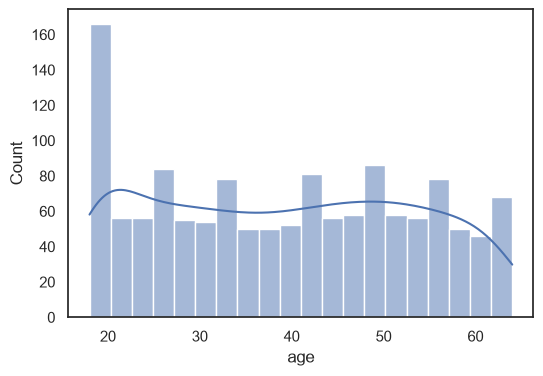

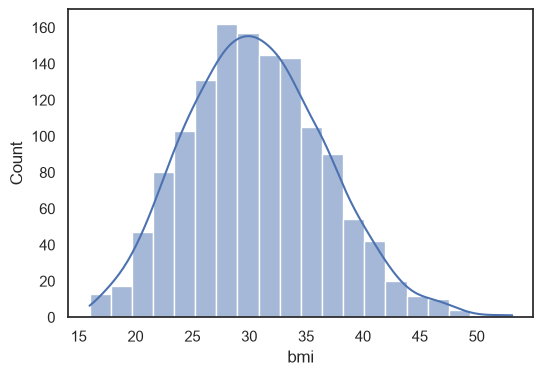

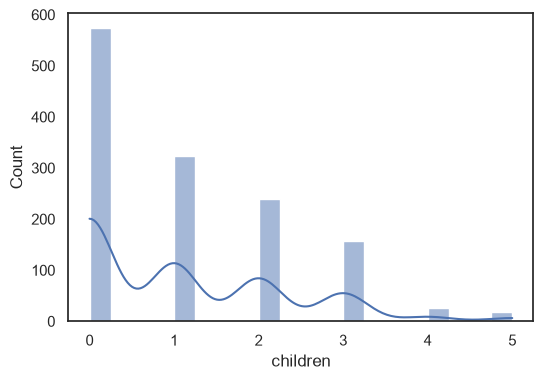

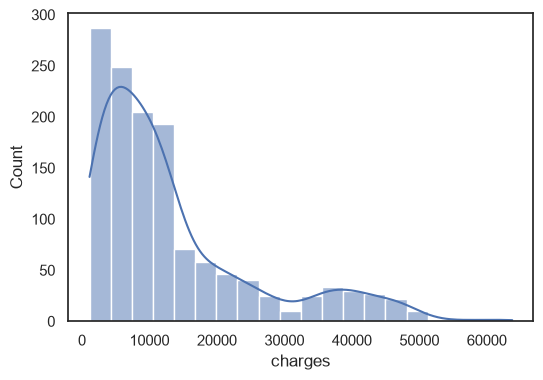

In [131]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

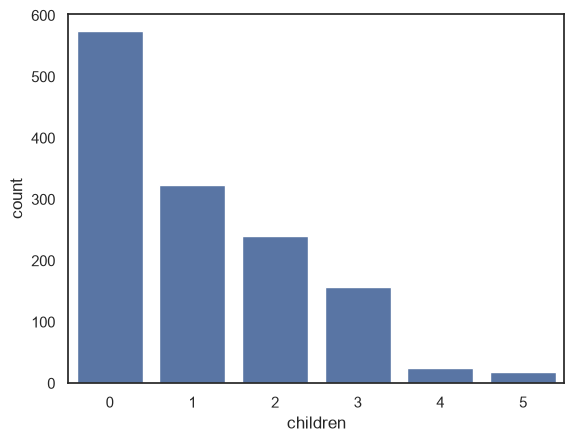

In [132]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

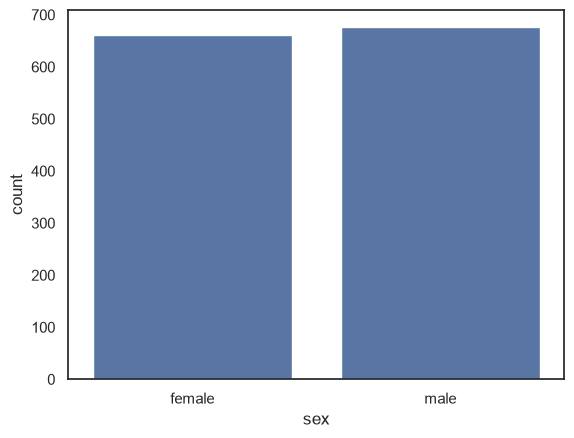

In [133]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

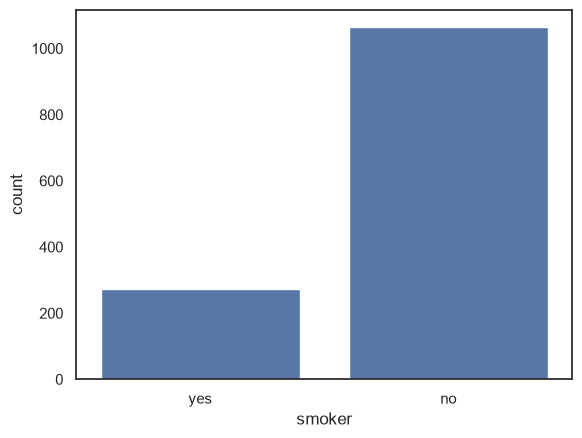

In [134]:
sns.countplot(x=df['smoker'])

<Axes: xlabel='region', ylabel='count'>

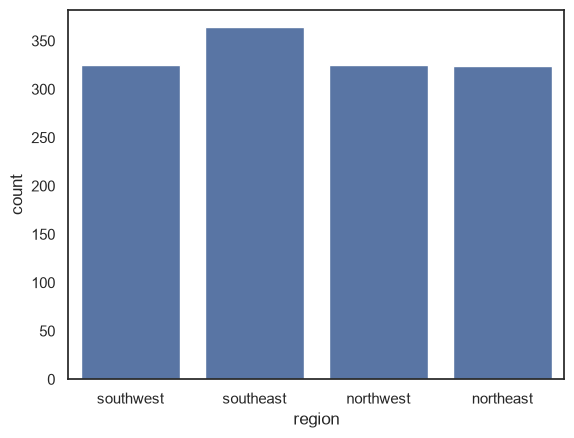

In [135]:
sns.countplot(x=df['region'])

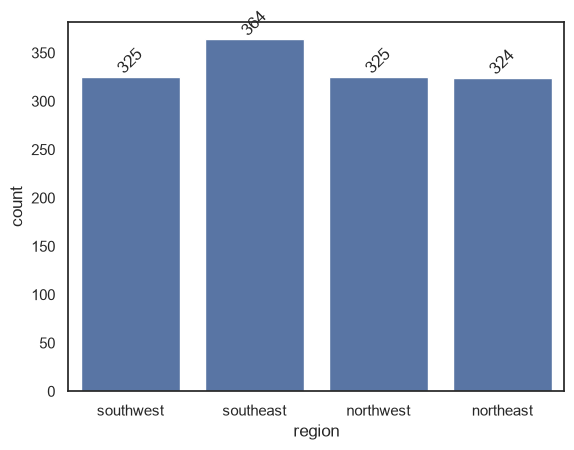

In [136]:
ax = sns.countplot(x=df['region'])

ax.bar_label(ax.containers[0], fmt='%.0f', rotation=45)

plt.show()

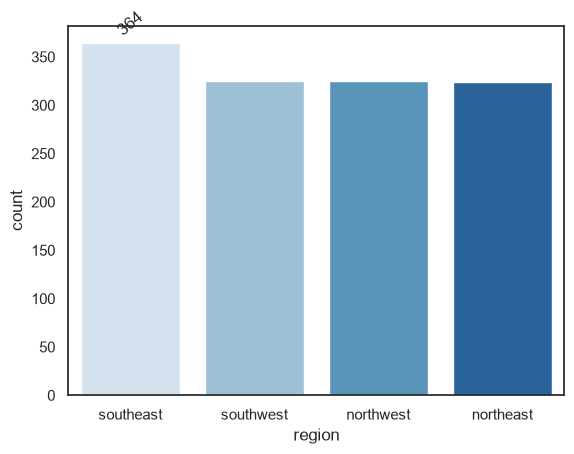

In [137]:

counts = df['region'].value_counts()

palette = sns.color_palette("Blues", len(counts))

ax = sns.countplot(
    data=df, 
    x="region", 
    order=counts.index, 
    palette=palette
)

ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, rotation=40)

plt.show()

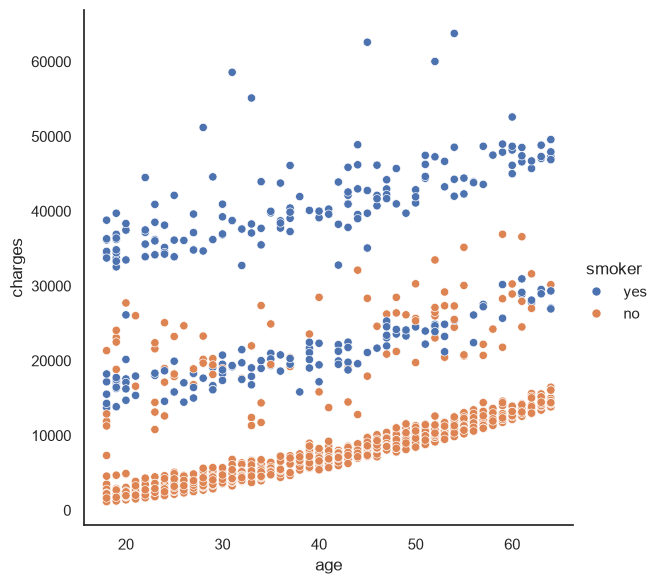

In [138]:
sns.set_theme(style="white")

sns.relplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker",
    height=6
)

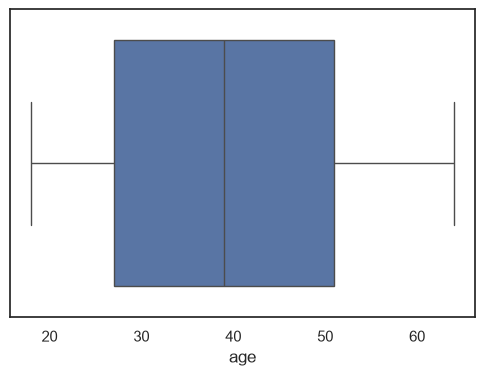

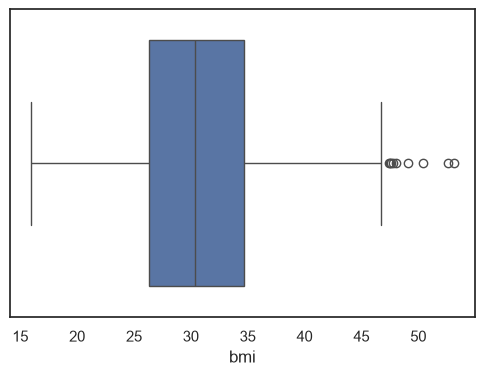

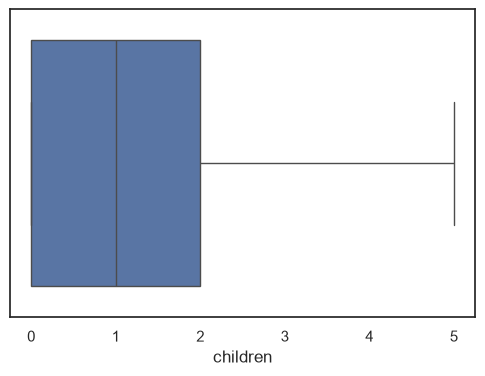

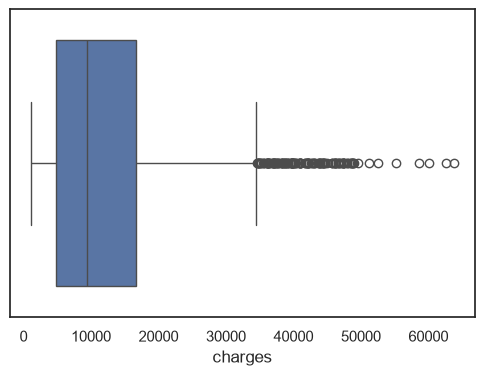

In [139]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])

<Axes: >

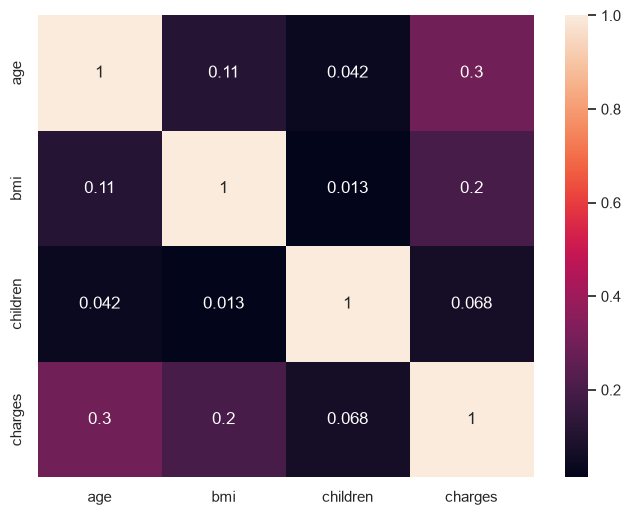

In [140]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [141]:
# Data cleaning

In [142]:
df_cleaned = df.copy()

In [143]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [144]:
df_cleaned.shape

(1338, 7)

In [145]:
df_cleaned.drop_duplicates(inplace = True)

In [146]:
df_cleaned.shape

(1337, 7)

In [147]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [148]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [149]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [150]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male":0, "female":1})

In [151]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [152]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no":0, "yes":1})

In [153]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [154]:
df_cleaned.rename(columns={'sex':'is_female', 
                           'smoker':'is_smoker'}, inplace = True)

In [155]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [156]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [157]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [158]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [159]:
df_cleaned = df_cleaned.astype(int)

In [160]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


In [161]:
# FEAUTE ENGINEERING AND EXTRACTION

<Axes: xlabel='bmi', ylabel='Count'>

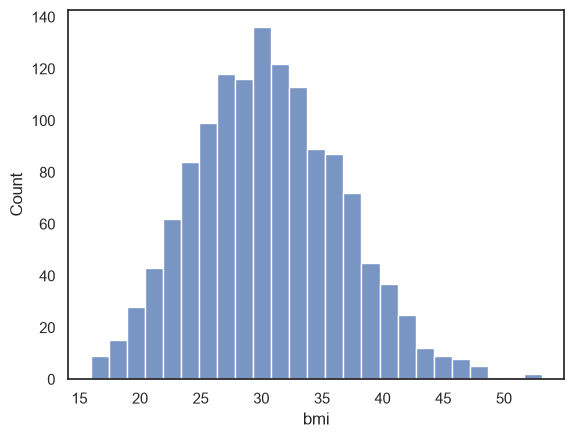

In [162]:
sns.histplot(df['bmi'])

In [163]:
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'],
                                    bins=[0,18.5,24.9, 29.9, float('inf')],
                                    labels = ['Underweight','Normal','Overweight','Obese'])

In [164]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [165]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [166]:
df_cleaned = df_cleaned.astype(int)

In [167]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [168]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [169]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [170]:
# PEARSON CORRELATION CALCULATION

In [171]:
from scipy.stats import pearsonr

In [172]:
selected_features = ['age', 'bmi', 'children', 'is_female', 'is_smoker', 'region_northwest', 'region_southeast',
                     'region_southwest', 'bmi_category_Normal','bmi_category_Overweight', 'bmi_category_Obese']

In [173]:
correlations = {feature:pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
                for feature in selected_features}

In [174]:
correlation_df = pd.DataFrame(list(correlations.items()),
                               columns=['Feature','Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_Obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_Normal,-0.104042


In [175]:
cat_features = ['is_female', 'is_smoker', 'region_northwest', 'region_southeast','region_southwest',
'bmi_category_Normal','bmi_category_Overweight','bmi_category_Obese']


In [176]:
from scipy.stats import chi2_contingency
alpha = 0.05

In [177]:
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results={}

In [178]:
for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col],df_cleaned['charges_bin'])
    chi2_stat,p_val,_,_=chi2_contingency(contingency)
    decision = 'Reject Null(Keep Feature)'if p_val < alpha else 'Accept Null(Drop Feature)'
    chi2_results[col]={'chi2_statistic':chi2_stat,'p_value':p_val,'Decision':decision}

In [179]:
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null(Keep Feature)
region_southeast,15.998167,0.001135,Reject Null(Keep Feature)
is_female,10.258784,0.01649,Reject Null(Keep Feature)
bmi_category_Obese,8.515711,0.036473,Reject Null(Keep Feature)
region_southwest,5.091893,0.165191,Accept Null(Drop Feature)
bmi_category_Overweight,4.25149,0.235557,Accept Null(Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null(Drop Feature)
region_northwest,1.13424,0.768815,Accept Null(Drop Feature)


In [180]:
final_df = df_cleaned[[
    'age', 'bmi', 'children', 'is_female', 'is_smoker', 'charges', 
    'region_northwest', 'region_southeast', 'region_southwest', 
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]]
final_df


,age,bmi,children,is_female,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,-0.517949,-0.909234,1,1,16884,0,0,1,0,1,0
1,-1.511647,0.462463,-0.079442,0,0,1725,0,1,0,0,0,1
2,-0.799350,0.462463,1.580143,0,0,4449,0,1,0,0,0,1
3,-0.443201,-1.334960,-0.909234,0,0,21984,1,0,0,1,0,0
4,-0.514431,-0.354547,-0.909234,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,0,10600,1,0,0,0,0,1
1334,-1.511647,0.135659,-0.909234,1,0,2205,0,0,0,0,0,1
1335,-1.511647,0.952670,-0.909234,1,0,1629,0,1,0,0,0,1
1336,-1.297958,-0.844753,-0.909234,1,0,2007,0,0,1,0,1,0


In [181]:
# X va Y ga ajratamiz

In [182]:
X = final_df.drop('charges', axis=1)
y = final_df['charges']

In [183]:
# Train va Test ga bo'lish

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [184]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
print("model muvaffaqiyatli o'qitildi")

model muvaffaqiyatli o'qitildi


In [185]:
# test qilib tekshiramiz

# yangi mijoz malumotlarini kiritamiz

yangi_mijoz = pd.DataFrame([{'age':-0.5, 
                             'bmi':0.2,
                             'children':0.0,
                             'is_female':0,
                             'is_smoker':1,
                             'region_northwest':0,
                             'region_southeast':1,
                             'region_southwest':0,
                             'bmi_category_Normal':0,
                             'bmi_category_Overweight':0,
                             'bmi_category_Obese':1 }])

yangi_mijoz = yangi_mijoz[X.columns]

taxminiy_charge = rf_model.predict(yangi_mijoz)

print(f"Taxmin qilingan sugurta xarajati: ${taxminiy_charge[0]:.2f}")
                             

Taxmin qilingan sugurta xarajati: $41295.45


In [186]:
# men farruhman. G'ulomjon telefon o'ynayabti

In [ ]:
### Mean Absolute Error

In [192]:
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)

pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test, pred)
roots = mse ** 0.5
r2 = r2_score(y_test,pred)

print("Mean absolute error:", mae)
print("Mean squared error: ", mse)
print("root error: ", roots)
print("R2: ", r2)

Mean absolute error: 2756.6787265014214
Mean squared error:  22656441.26992019
root error:  4759.878283099284
R2:  0.8767037224558561


In [193]:
rf_model.fit(X_train,y_train)
pred = rf_model.predict(X_test)

In [194]:
natija = pd.DataFrame({
    "Actual": y_test,
    "Predicted":pred
})

# Error = Actual - Predicted
natija["Error"] = natija["Actual"] - natija["Predicted"]
print(natija)

      Actual   Predicted      Error
900     8688   8962.0500  -274.0500
1064    5708  10738.3700 -5030.3700
1256   11436  12759.8900 -1323.8900
298    38746  42638.3600 -3892.3600
237     4463   6666.8100 -2203.8100
...      ...         ...        ...
534    13831  14394.5125  -563.5125
542    13887  14239.6800  -352.6800
760     3925   8894.8500 -4969.8500
1284   47403  48187.2400  -784.2400
1285    8534  16126.1000 -7592.1000

[268 rows x 3 columns]


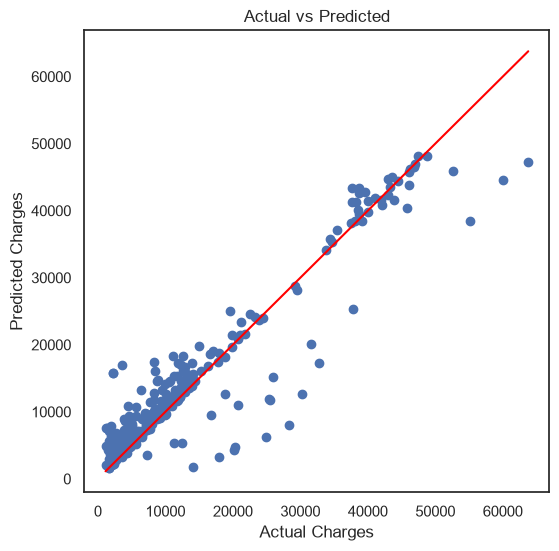

In [195]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [199]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
4                 is_smoker    0.601070
0                       age    0.143875
1                       bmi    0.108757
10       bmi_category_Obese    0.080506
2                  children    0.025773
3                 is_female    0.010026
5          region_northwest    0.009012
6          region_southeast    0.008548
7          region_southwest    0.006094
9   bmi_category_Overweight    0.003218
8       bmi_category_Normal    0.003122


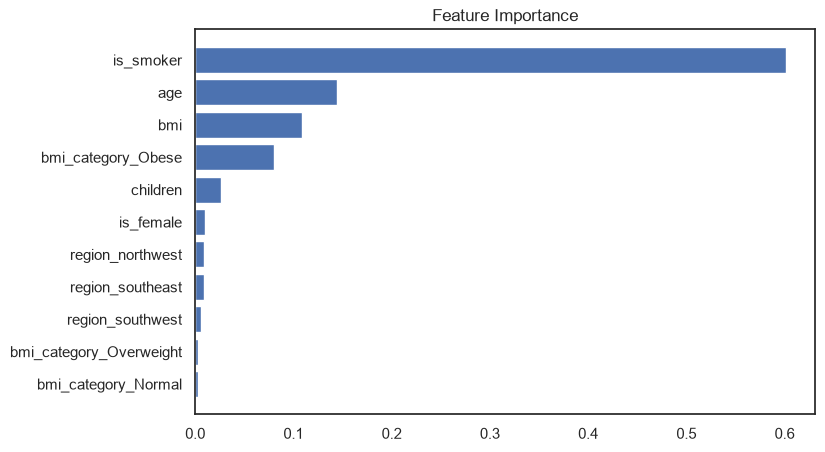

In [200]:
plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

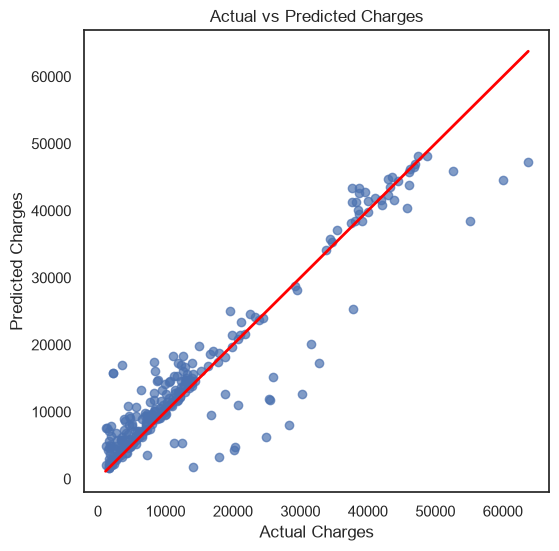

In [201]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

In [202]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

results["Error"] = abs(results["Actual"] - results["Predicted"])

results = results.sort_values(
    by="Error",
    ascending=False
)

print(results.head(10))

      Actual     Predicted         Error
987    28340   8098.181667  20241.818333
637    24915   6287.440000  18627.560000
115    30259  12663.260000  17595.740000
819    55135  38460.070000  16674.930000
543    63770  47299.480000  16470.520000
306    20177   4365.790000  15811.210000
291    20277   4799.050000  15477.950000
128    32734  17258.840000  15475.160000
1230   60021  44623.590000  15397.410000
554    17878   3254.880000  14623.120000
